# Model Comparison – ENADE 2022 (UFJF)

This notebook compares the supervised learning models used in the project,
summarizing their predictive performance and presenting a simple interpretation
of the results.

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("../data/processed/enade_ufjf_2022_model.csv")
df.head()

,CO_CURSO,NT_GER,y_perf
0,1105396,18.9,low
1,1105396,20.8,low
2,1105396,25.8,low
3,1105396,26.2,low
4,1105396,29.5,low


In [20]:
X = df.drop(columns=["y_perf", "NT_GER"])
y = df["y_perf"]

print("X shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (813, 1)

Class distribution:
y_perf
high      275
medium    270
low       268
Name: count, dtype: int64


In [21]:
categorical_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [24]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    predictions[name] = y_pred
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro")
    })

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
results_df

,Model,Accuracy,F1_macro
0,Logistic Regression,0.582822,0.581504
1,Decision Tree,0.582822,0.581504
2,Random Forest,0.582822,0.581504


In [25]:
for name, y_pred in predictions.items():
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

        high       0.58      0.62      0.60        55
         low       0.74      0.72      0.73        54
      medium       0.43      0.41      0.42        54

    accuracy                           0.58       163
   macro avg       0.58      0.58      0.58       163
weighted avg       0.58      0.58      0.58       163


Decision Tree
              precision    recall  f1-score   support

        high       0.58      0.62      0.60        55
         low       0.74      0.72      0.73        54
      medium       0.43      0.41      0.42        54

    accuracy                           0.58       163
   macro avg       0.58      0.58      0.58       163
weighted avg       0.58      0.58      0.58       163


Random Forest
              precision    recall  f1-score   support

        high       0.58      0.62      0.60        55
         low       0.74      0.72      0.73        54
      medium       0.43 

In [26]:
cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1_macro"
    )
    
    cv_results.append({
        "Model": name,
        "CV_F1_Mean": scores.mean(),
        "CV_F1_Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_F1_Mean", ascending=False)
cv_results_df

,Model,CV_F1_Mean,CV_F1_Std
0,Logistic Regression,0.230194,0.071565
1,Decision Tree,0.218842,0.056693
2,Random Forest,0.211368,0.058784


Best model: Logistic Regression


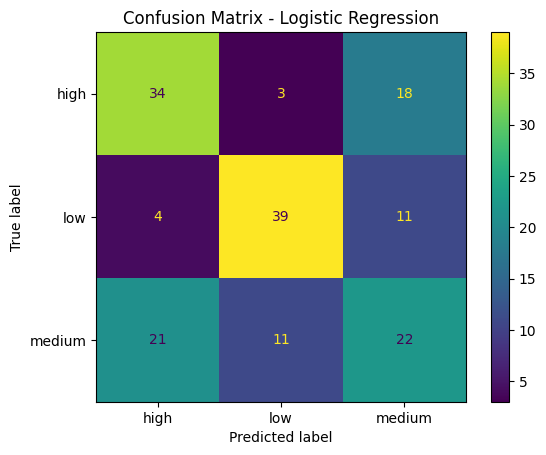

In [27]:
best_model_name = results_df.iloc[0]["Model"]
best_y_pred = predictions[best_model_name]

print(f"Best model: {best_model_name}")

ConfusionMatrixDisplay.from_predictions(y_test, best_y_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [28]:
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

ohe = rf_model.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_features)

importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
10,CO_CURSO_1132074,0.218691
1,CO_CURSO_13090,0.149460
3,CO_CURSO_13113,0.117821
2,CO_CURSO_13107,0.086708
14,CO_CURSO_1183351,0.077551
12,CO_CURSO_1178683,0.076564
9,CO_CURSO_1105396,0.058181
0,CO_CURSO_13089,0.044362
7,CO_CURSO_27657,0.036046
5,CO_CURSO_21860,0.031350


## Discussion

The comparison shows that the evaluated models achieve moderate predictive
performance in the ENADE classification task. Cross-validation helps verify
that the results are relatively consistent, while the confusion matrix provides
a better understanding of classification errors.

Feature importance from the Random Forest model also helps identify which
institutional and course-level variables contribute the most to the predictions.